# Activity 5 — Breast Cancer Dataset Exploration

This activity uses scikit-learn's built-in Breast Cancer Wisconsin dataset, which is the dataset referred to by the lab's `data.keys()`, `data.target_names`, `data.feature_names`, `data.data`, and `data.target` instructions.

### Goal
- inspect the dataset like the Iris example,
- introduce 5 missing values into Mean Radius,
- fill them appropriately,
- inspect malignant vs benign class distribution,
- determine whether the classes are imbalanced,
- demonstrate class weighting if imbalance is present.

**Important:** We do not need to use SMOTE just because the task mentions it. If the imbalance is modest, class weighting is a simple way to account for it during model training.

In [12]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

print("Data keys:")
print(data.keys())

print("\nTarget names:")
print(data.target_names)

print("\nNumber of samples:", data.data.shape[0])
print("Number of features:", data.data.shape[1])

print("\nFeature names:")
print(data.feature_names)

print("\ndata.data shape:", data.data.shape)
print("data.target shape:", data.target.shape)

Data keys:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

Target names:
['malignant' 'benign']

Number of samples: 569
Number of features: 30

Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

data.data shape: (569, 30)
data.target shape: (569,)


## Task 1 — Explore the DataFrame

The dataset has one row per tumor sample and one column per numerical feature.

`data.data` contains the feature values.

`data.target` contains the class labels.

The target names tell us what the numerical labels mean.

In [13]:
print("First five rows:")
print(df.head())

print("\nDataFrame shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

First five rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimete

## Task 2 — Introduce and handle missing values

The original dataset has no missing values. To practice missing-value handling, we randomly select 5 rows and set their **mean radius** value to `NaN`.

We use the **median** to fill them because median is robust to unusually large/small measurements and is a safe default for a skewed numerical feature.

In [14]:
np.random.seed(42)

mean_radius_col = "mean radius"

random_indices = np.random.choice(
    df.index,
    size=5,
    replace=False
)

df.loc[random_indices, mean_radius_col] = np.nan

print("Missing values before handling:")
print(df[mean_radius_col].isna().sum())

median_radius = df[mean_radius_col].median()

df[mean_radius_col] = df[mean_radius_col].fillna(median_radius)

print("\nMedian used:", median_radius)
print("Missing values after handling:")
print(df[mean_radius_col].isna().sum())

Missing values before handling:
5

Median used: 13.375
Missing values after handling:
0


## Task 3 — Check target/class distribution

The target contains two classes:
- `0` = malignant
- `1` = benign

We count both classes and calculate their proportions.

A common simple check is to compare the minority class proportion with the majority class proportion. The exact threshold for calling a dataset "imbalanced" depends on context; for this lab, we report the proportions rather than pretending there is one universal cutoff.

In [15]:
target_series = pd.Series(data.target, name="target")

class_counts = target_series.value_counts().sort_index()

print("Class counts:")
for label, count in class_counts.items():
    print(f"{label} ({data.target_names[label]}): {count}")

class_percentages = target_series.value_counts(normalize=True).sort_index() * 100

print("\nClass percentages:")
for label, percentage in class_percentages.items():
    print(f"{data.target_names[label]}: {percentage:.2f}%")

imbalance_ratio = class_counts.max() / class_counts.min()

print(f"\nMajority/minority ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio >= 1.5:
    print("The classes show a noticeable imbalance.")
else:
    print("The classes are relatively close in size.")

Class counts:
0 (malignant): 212
1 (benign): 357

Class percentages:
malignant: 37.26%
benign: 62.74%

Majority/minority ratio: 1.68:1
The classes show a noticeable imbalance.


## Task 4 — Visualize class distribution

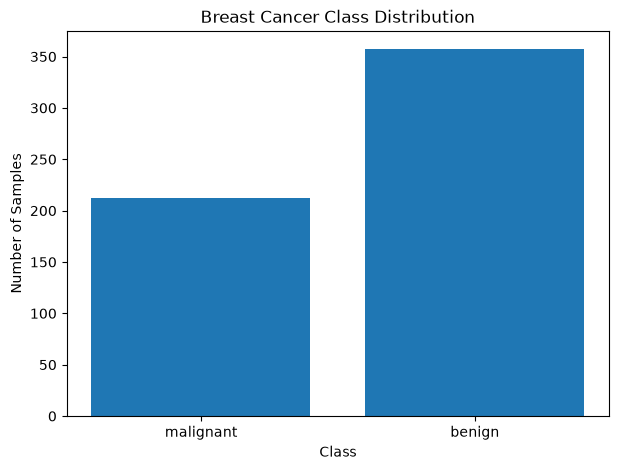

In [16]:
labels = [data.target_names[i] for i in class_counts.index]

plt.figure(figsize=(7, 5))
plt.bar(labels, class_counts.values)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Breast Cancer Class Distribution")
plt.show()

## Task 5 — Apply class weighting when appropriate

Class weighting is applied **during model training**, not by changing the dataset rows.

`class_weight="balanced"` tells a classifier to give more importance to the minority class.

We demonstrate this with Logistic Regression. The comparison shows class counts before and after; importantly, the counts do **not** change because class weighting does not duplicate or remove samples.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Class counts BEFORE class weighting:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClass counts AFTER class weighting:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nClassification report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=data.target_names
    )
)

Class counts BEFORE class weighting:
0    170
1    285
Name: count, dtype: int64

Class counts AFTER class weighting:
0    170
1    285
Name: count, dtype: int64

Classification report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



### Final interpretation

- `data.keys()` shows the dataset components available from scikit-learn.
- `data.data.shape` gives the number of samples and features.
- Five missing values were artificially introduced into `mean radius`.
- Median imputation was used because it is robust to extreme numerical values.
- The target has malignant and benign classes with different frequencies.
- If the class distribution is noticeably imbalanced, `class_weight="balanced"` makes the classifier pay more attention to the minority class.
- Class weighting does **not** change the class counts. It changes the importance assigned to observations during model fitting.